min scaled sizes: 50.0, median scaled sizes: 81.36709056074886, max scaled sizes: 500.0
Size metric 'number_of_sig_info_in_pathway': min=0, median=5421.0, max=77771
Scaled marker sizes for legend: min=50.0, median=81.4, max=500.0


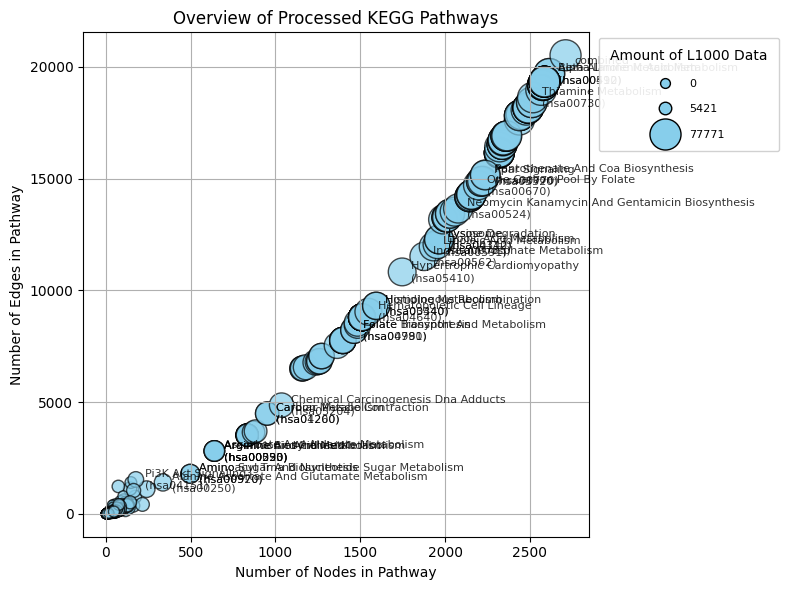

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from matplotlib.lines import Line2D

# ========================
# CONFIGURATION
# ========================
# Metrics to use
x_metric = "number_of_nodes"
y_metric = "number_of_edges"
size_metric = "number_of_sig_info_in_pathway"

# Plot labels and title
xlabel = "Number of Nodes in Pathway"
ylabel = "Number of Edges in Pathway"
title = "Overview of Processed KEGG Pathways"

# Percentile for isolated points annotation
isolated_percentile = 92  # top 8%

# ------------------------
# Load data
# ------------------------
with open("kegg_data/kegg_nodes_metrics.json") as f:
    data = json.load(f)

names = list(data.keys())
x = np.array([data[name][x_metric] for name in names])
y = np.array([data[name][y_metric] for name in names])
sizes = np.array([data[name][size_metric] for name in names])

# ------------------------
# Helper functions
# ------------------------
def scale_sizes(values, min_size=50, max_size=500):
    """Scale marker sizes for scatter plot."""
    vmin, vmax = np.min(values), np.max(values)
    if vmax == vmin:
        return np.full_like(values, min_size, dtype=float)
    return min_size + (values - vmin) / (vmax - vmin) * (max_size - min_size)

def find_isolated_points(x, y, percentile=92, k=5):
    """Return indices of points that are isolated based on k-nearest neighbor distance."""
    coords = np.column_stack([x, y])
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
    distances, _ = nbrs.kneighbors(coords)
    avg_dist = distances[:, 1:].mean(axis=1)  # exclude self-distance
    threshold = np.percentile(avg_dist, percentile)
    isolated_idx = np.where(avg_dist >= threshold)[0]
    return isolated_idx

# ------------------------
# Plot
# ------------------------
plt.figure(figsize=(8, 6))

# Scatter plot
scaled_sizes = scale_sizes(sizes)
sc = plt.scatter(x, y, s=scaled_sizes, alpha=0.7, edgecolors='k', c='skyblue')

print(f"min scaled sizes: {np.min(scaled_sizes)}, median scaled sizes: {np.median(scaled_sizes)}, max scaled sizes: {np.max(scaled_sizes)}")
# Annotate isolated points
isolated_idx = find_isolated_points(x, y, percentile=isolated_percentile)
for i in isolated_idx:
    name = names[i]
    if "(" in name:
        name = name.replace("(", "\n(")
    plt.text(x[i]+0.02*max(x), y[i]-0.02*max(y), name, fontsize=8, alpha=0.8)


# ------------------------
# Correct size legend
# ------------------------
# Calculate min, median, max of the actual data
size_min = np.min(sizes)
size_median = np.median(sizes)
size_max = np.max(sizes)

min_size = 50
max_size = 500

# Apply scaling to individual legend values
# These represent marker AREA (same as scatter plot's 's' parameter)
marker_min = min_size + (size_min - np.min(sizes)) / (np.max(sizes) - np.min(sizes)) * (max_size - min_size)
marker_median = min_size + (size_median - np.min(sizes)) / (np.max(sizes) - np.min(sizes)) * (max_size - min_size)
marker_max = min_size + (size_max - np.min(sizes)) / (np.max(sizes) - np.min(sizes)) * (max_size - min_size)

print(f"Size metric '{size_metric}': min={size_min}, median={size_median}, max={size_max}")
print(f"Scaled marker sizes for legend: min={marker_min:.1f}, median={marker_median:.1f}, max={marker_max:.1f}")

# Create custom legend handles
# Convert from area (scatter's 's') to linear size (Line2D's 'markersize')
# The correct conversion is: markersize = sqrt(area), NOT sqrt(area/pi)
# Create custom legend handles
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', 
           markeredgecolor='k', markersize=np.sqrt(marker_min), label=f'{int(size_min)}'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', 
           markeredgecolor='k', markersize=np.sqrt(marker_median), label=f'{int(size_median)}'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', 
           markeredgecolor='k', markersize=np.sqrt(marker_max), label=f'{int(size_max)}')
]

# Better legend placement and styling
# bbox_to_anchor=(1.05, 1) places legend outside on the right
plt.legend(
    handles=legend_handles,
    title="Amount of L1000 Data",
    fontsize=8,
    title_fontsize=10,
    frameon=True,
    framealpha=0.9,
    loc='upper left',           # anchor point of the legend box
    bbox_to_anchor=(1.01, 1),   # position relative to the axes (x, y)
    borderpad=1,
    labelspacing=1.4,           # spacing between entries
    handletextpad=1.2,          # spacing between marker and label
    handlelength=2               # length of marker in legend
)


plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
plt.grid(True)
plt.tight_layout()
plt.show()
